# Frozen Lake – Q-Learning
### Projekt 3: Podstawy Gymnasium
**Algorytm:** Q-Learning z eksploracją ε-greedy  
**Środowisko:** FrozenLake-v1 (4×4, śliskie podłoże)  
**Współczynnik dyskontowy:** γ = 0.9

## 1. Importy i konfiguracja środowiska

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time

# Sprawdzenie wersji
print(f"gymnasium version: {gym.__version__}")
print(f"numpy version:     {np.__version__}")

gymnasium version: 1.2.3
numpy version:     2.4.2


## 2. Hiperparametry

In [2]:
# ── Hiperparametry ──────────────────────────────────────────────────────────
EPISODES       = 10_000   # liczba epizodów treningowych
MAX_STEPS      = 100      # maksymalna liczba kroków w epizodzie
ALPHA          = 0.8      # współczynnik uczenia (learning rate)
GAMMA          = 0.9      # współczynnik dyskontowy (wymagany)
EPSILON_START  = 1.0      # początkowe ε – pełna eksploracja
EPSILON_MIN    = 0.01     # minimalne ε
EPSILON_DECAY  = 0.9995   # wykładnicze zanikanie ε na epizod

EVAL_WINDOW    = 100      # okno wygładzania krzywej uczenia
SEED           = 42
MAP_NAME       = "4x4"    # "4x4" lub "8x8"
IS_SLIPPERY    = True     # True = śliska podłoga (stochastyczne przejścia)

print("Hiperparametry:")
print(f"  Epizody:     {EPISODES}")
print(f"  Max kroków:  {MAX_STEPS}")
print(f"  α (lr):      {ALPHA}")
print(f"  γ (discount):{GAMMA}")
print(f"  ε:           {EPSILON_START} → {EPSILON_MIN}  (decay={EPSILON_DECAY})")
print(f"  Mapa:        {MAP_NAME}, is_slippery={IS_SLIPPERY}")

Hiperparametry:
  Epizody:     10000
  Max kroków:  100
  α (lr):      0.8
  γ (discount):0.9
  ε:           1.0 → 0.01  (decay=0.9995)
  Mapa:        4x4, is_slippery=True


## 3. Opis środowiska Frozen Lake

Frozen Lake to siatka 4×4 (lub 8×8), w której agent porusza się po zamarzniętym jeziorze:

| Symbol | Opis |
|--------|------|
| `S` | Start |
| `F` | Frozen – bezpieczne pole |
| `H` | Hole – dziura (epizod kończy się porażką) |
| `G` | Goal – cel (nagroda = 1) |

**Akcje:** LEFT (0), DOWN (1), RIGHT (2), UP (3)  
**is_slippery=True:** agent przesuwa się w losowym kierunku prostopadłym z prawdopodobieństwem 2/3.

In [3]:
# Wyświetl mapę środowiska
env_view = gym.make("FrozenLake-v1", map_name=MAP_NAME,
                    is_slippery=IS_SLIPPERY, render_mode="ansi")
obs, _ = env_view.reset(seed=SEED)
print(env_view.render())
print(f"Przestrzeń stanów:  {env_view.observation_space}  ({env_view.observation_space.n} stanów)")
print(f"Przestrzeń akcji:   {env_view.action_space}  ({env_view.action_space.n} akcje)")
env_view.close()


SFFF
FHFH
FFFH
HFFG

Przestrzeń stanów:  Discrete(16)  (16 stanów)
Przestrzeń akcji:   Discrete(4)  (4 akcje)


## 4. Algorytm Q-Learning

Q-Learning to algorytm uczenia ze wzmocnieniem oparty na tablicy Q(s, a).  
Reguła aktualizacji (równanie Bellmana):

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

- **α** – współczynnik uczenia  
- **γ** – współczynnik dyskontowy (= 0.9)  
- **ε-greedy** – z prawdopodobieństwem ε losowa akcja (eksploracja), w przeciwnym razie `argmax Q(s, ·)` (eksploatacja)  
- **ε maleje wykładniczo** w trakcie treningu: agent stopniowo przechodzi od eksploracji do eksploatacji

## 5. Trening agenta

In [4]:
env = gym.make("FrozenLake-v1", map_name=MAP_NAME, is_slippery=IS_SLIPPERY)
n_states  = env.observation_space.n
n_actions = env.action_space.n

# Inicjalizacja tablicy Q zerami
rng = np.random.default_rng(SEED)
Q = np.zeros((n_states, n_actions))

epsilon      = EPSILON_START
all_rewards  = []        # nagroda z każdego epizodu (0 lub 1)
episode_lengths = []     # liczba kroków w każdym epizodzie
epsilon_history = []     # historia ε do wykresu

start_time = time.time()

for episode in range(EPISODES):
    state, _ = env.reset(seed=SEED + episode)
    total_reward = 0

    for step in range(MAX_STEPS):
        # Polityka ε-greedy
        if rng.random() < epsilon:
            action = env.action_space.sample()          # eksploracja
        else:
            action = int(np.argmax(Q[state]))           # eksploatacja

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Aktualizacja Q (reguła Bellmana)
        best_next = np.max(Q[next_state]) if not terminated else 0.0
        td_target = reward + GAMMA * best_next
        Q[state, action] += ALPHA * (td_target - Q[state, action])

        state = next_state
        total_reward += reward
        if done:
            break

    all_rewards.append(total_reward)
    episode_lengths.append(step + 1)

    # Zanikanie ε
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
    epsilon_history.append(epsilon)

env.close()

elapsed = time.time() - start_time
print(f"Trening zakończony w {elapsed:.1f}s")
print(f"Końcowe ε: {epsilon:.4f}")

# Statystyki po segmentach po 1000 epizodów
print("\nWskaźnik sukcesu (co 1000 epizodów):")
for i in range(0, EPISODES, 1000):
    sr = np.mean(all_rewards[i:i+1000]) * 100
    print(f"  Epizody {i+1:>6}–{i+1000:<6}: {sr:.1f}%")

Trening zakończony w 4.0s
Końcowe ε: 0.0100

Wskaźnik sukcesu (co 1000 epizodów):
  Epizody      1–1000  : 1.8%
  Epizody   1001–2000  : 4.0%
  Epizody   2001–3000  : 5.8%
  Epizody   3001–4000  : 10.5%
  Epizody   4001–5000  : 15.1%
  Epizody   5001–6000  : 19.5%
  Epizody   6001–7000  : 29.3%
  Epizody   7001–8000  : 36.3%
  Epizody   8001–9000  : 40.2%
  Epizody   9001–10000 : 48.3%


## 6. Krzywa uczenia

Wykres zapisany: learning_curve.png


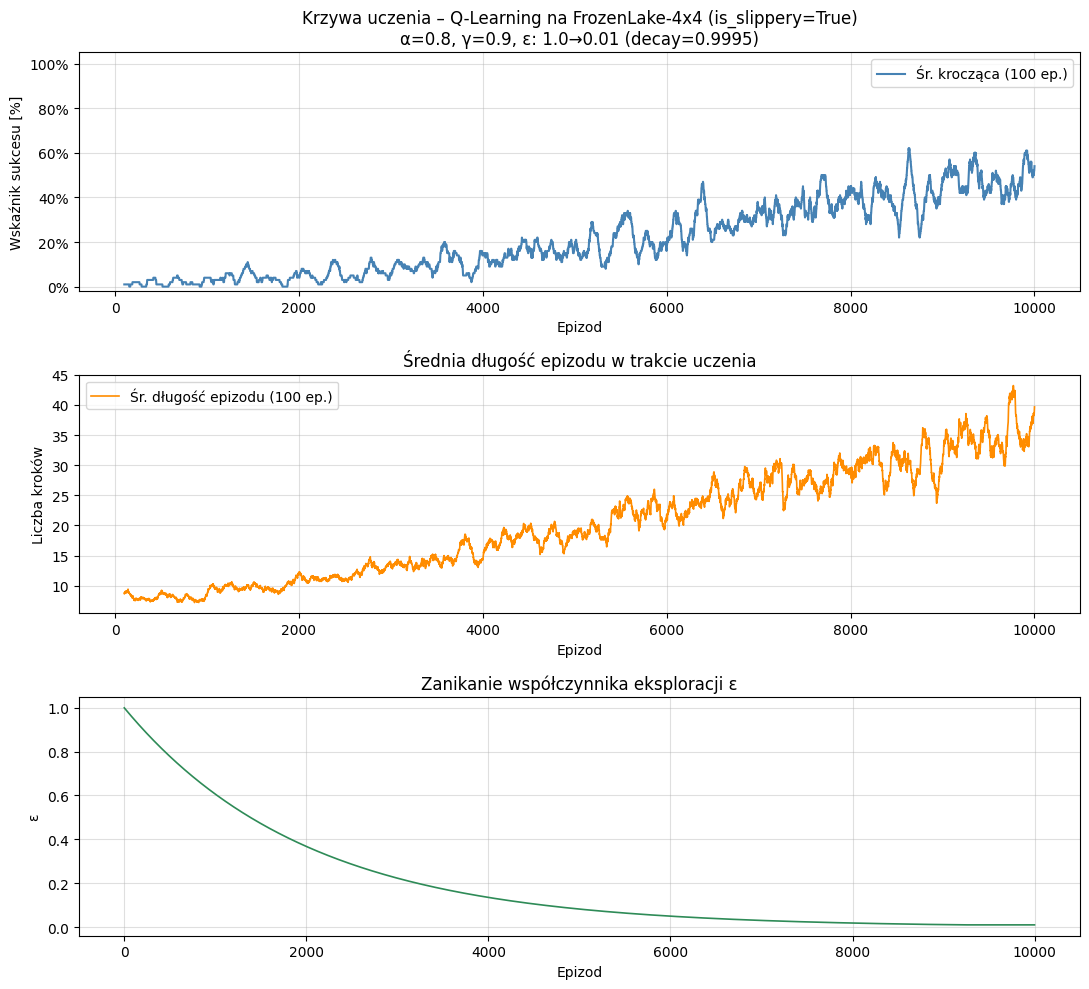

In [5]:
window   = EVAL_WINDOW
smoothed = np.convolve(all_rewards, np.ones(window) / window, mode='valid')
x_smooth = np.arange(window, EPISODES + 1)
ep_len_smooth = np.convolve(episode_lengths, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(3, 1, figsize=(11, 10))

# ── Wykres 1: Wskaźnik sukcesu (krzywa uczenia) ──
axes[0].plot(x_smooth, smoothed * 100, color="steelblue", linewidth=1.5,
             label=f"Śr. krocząca ({window} ep.)")
axes[0].set_xlabel("Epizod")
axes[0].set_ylabel("Wskaźnik sukcesu [%]")
axes[0].set_title(
    f"Krzywa uczenia – Q-Learning na FrozenLake-{MAP_NAME} (is_slippery={IS_SLIPPERY})\n"
    f"α={ALPHA}, γ={GAMMA}, ε: {EPSILON_START}→{EPSILON_MIN} (decay={EPSILON_DECAY})"
)
axes[0].legend()
axes[0].set_ylim(-2, 105)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[0].grid(True, alpha=0.4)

# ── Wykres 2: Długość epizodów ──
axes[1].plot(x_smooth, ep_len_smooth, color="darkorange", linewidth=1.2,
             label=f"Śr. długość epizodu ({window} ep.)")
axes[1].set_xlabel("Epizod")
axes[1].set_ylabel("Liczba kroków")
axes[1].set_title("Średnia długość epizodu w trakcie uczenia")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

# ── Wykres 3: Zanikanie ε ──
axes[2].plot(range(EPISODES), epsilon_history, color="seagreen", linewidth=1.2)
axes[2].set_xlabel("Epizod")
axes[2].set_ylabel("ε")
axes[2].set_title("Zanikanie współczynnika eksploracji ε")
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150, bbox_inches="tight")
print("Wykres zapisany: learning_curve.png")
plt.show()

## 7. Ewaluacja wyuczonej polityki

In [6]:
N_EVAL = 1000
env_eval = gym.make("FrozenLake-v1", map_name=MAP_NAME, is_slippery=IS_SLIPPERY)
successes = 0

for ep in range(N_EVAL):
    s, _ = env_eval.reset(seed=99000 + ep)
    for _ in range(MAX_STEPS):
        a = int(np.argmax(Q[s]))                        # czysta polityka (ε=0)
        s, r, terminated, truncated, _ = env_eval.step(a)
        if terminated or truncated:
            successes += r
            break

env_eval.close()
success_rate = successes / N_EVAL * 100
print(f"Ewaluacja ({N_EVAL} epizodów, czysta polityka greedy):")
print(f"  Wskaźnik sukcesu: {success_rate:.1f}%")

Ewaluacja (1000 epizodów, czysta polityka greedy):
  Wskaźnik sukcesu: 75.0%


## 8. Wizualizacja tablicy Q i wyuczonej polityki

Wyuczona polityka (najlepsza akcja w każdym stanie):
+----+----+----+----+
| ←  | ↑  | ←  | ↑  |
+----+----+----+----+
| ←  | H  | ←  | H  |
+----+----+----+----+
| ↑  | ↓  | ←  | H  |
+----+----+----+----+
| H  | →  | ↓  | G  |
+----+----+----+----+

Wykres zapisany: q_table_visualization.png


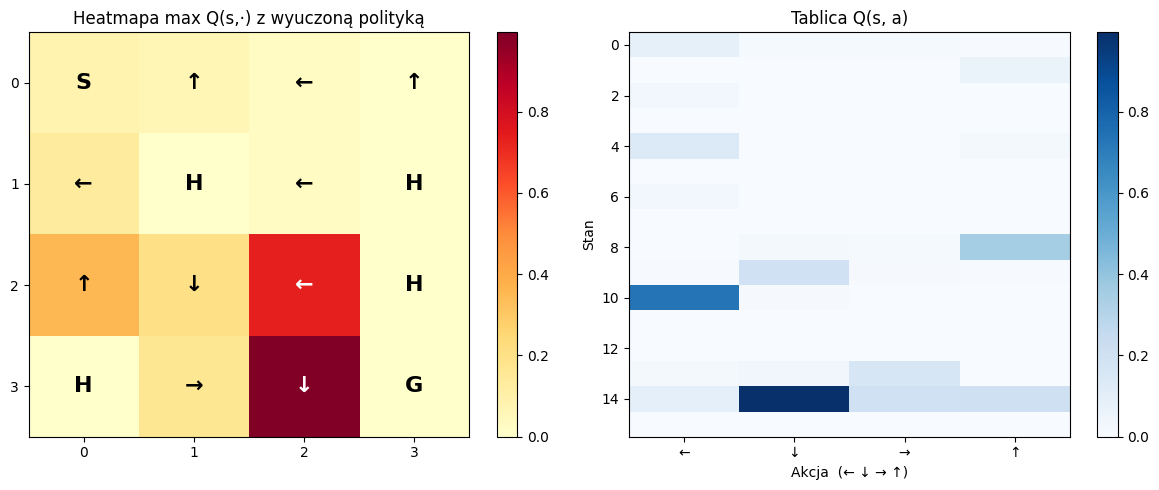

In [7]:
action_names  = ["←", "↓", "→", "↑"]
action_labels = {0: "←", 1: "↓", 2: "→", 3: "↑"}

side = int(np.sqrt(n_states))

# Mapa (zdefiniowana jako w Gymnasium)
frozen_map = [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG"
]

# ── Wyuczona polityka jako strzałki ──
print("Wyuczona polityka (najlepsza akcja w każdym stanie):")
print("+" + "----+" * side)
for r in range(side):
    row_str = "|"
    for c in range(side):
        s = r * side + c
        cell_char = frozen_map[r][c]
        if cell_char in ("H", "G"):
            row_str += f" {cell_char}  |"
        else:
            a = int(np.argmax(Q[s]))
            row_str += f" {action_labels[a]}  |"
    print(row_str)
    print("+" + "----+" * side)

# ── Heatmapa wartości max Q ──
max_Q = np.max(Q, axis=1).reshape(side, side)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(max_Q, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=axes[0])
for r in range(side):
    for c in range(side):
        s = r * side + c
        cell_char = frozen_map[r][c]
        label = cell_char if cell_char in ("H", "G", "S") else action_labels[int(np.argmax(Q[s]))]
        axes[0].text(c, r, label, ha="center", va="center",
                     fontsize=16, fontweight="bold",
                     color="black" if max_Q[r, c] < 0.5 else "white")
axes[0].set_title("Heatmapa max Q(s,·) z wyuczoną polityką")
axes[0].set_xticks(range(side))
axes[0].set_yticks(range(side))

# ── Tablica Q – wszystkie akcje ──
im2 = axes[1].imshow(Q, cmap="Blues", aspect="auto")
plt.colorbar(im2, ax=axes[1])
axes[1].set_xlabel("Akcja  (← ↓ → ↑)")
axes[1].set_ylabel("Stan")
axes[1].set_title("Tablica Q(s, a)")
axes[1].set_xticks(range(n_actions))
axes[1].set_xticklabels(action_names)

plt.tight_layout()
plt.savefig("q_table_visualization.png", dpi=150, bbox_inches="tight")
print("\nWykres zapisany: q_table_visualization.png")
plt.show()

## 9. Demonstracja jednego epizodu

In [8]:
env_demo = gym.make("FrozenLake-v1", map_name=MAP_NAME,
                    is_slippery=IS_SLIPPERY, render_mode="ansi")
state, _ = env_demo.reset(seed=7)
print("Stan początkowy:")
print(env_demo.render())

for step in range(MAX_STEPS):
    action = int(np.argmax(Q[state]))
    state, reward, terminated, truncated, _ = env_demo.step(action)
    print(f"Krok {step+1}: akcja = {action_labels[action]}")
    print(env_demo.render())
    if terminated or truncated:
        if reward == 1:
            print("SUKCES! Agent dotarł do celu (G).")
        else:
            print("PORAŻKA – agent wpadł do dziury (H).")
        break

env_demo.close()

Stan początkowy:

SFFF
FHFH
FFFH
HFFG

Krok 1: akcja = ←
  (Left)
SFFF
FHFH
FFFH
HFFG

Krok 2: akcja = ←
  (Left)
SFFF
FHFH
FFFH
HFFG

Krok 3: akcja = ↑
  (Up)
SFFF
FHFH
FFFH
HFFG

Krok 4: akcja = ↓
  (Down)
SFFF
FHFH
FFFH
HFFG

Krok 5: akcja = ↑
  (Up)
SFFF
FHFH
FFFH
HFFG

Krok 6: akcja = ↑
  (Up)
SFFF
FHFH
FFFH
HFFG

Krok 7: akcja = ↓
  (Down)
SFFF
FHFH
FFFH
HFFG

Krok 8: akcja = ←
  (Left)
SFFF
FHFH
FFFH
HFFG

Krok 9: akcja = ↓
  (Down)
SFFF
FHFH
FFFH
HFFG

Krok 10: akcja = ↓
  (Down)
SFFF
FHFH
FFFH
HFFG

Krok 11: akcja = →
  (Right)
SFFF
FHFH
FFFH
HFFG

Krok 12: akcja = →
  (Right)
SFFF
FHFH
FFFH
HFFG

Krok 13: akcja = →
  (Right)
SFFF
FHFH
FFFH
HFFG

Krok 14: akcja = ↓
  (Down)
SFFF
FHFH
FFFH
HFFG

Krok 15: akcja = ↓
  (Down)
SFFF
FHFH
FFFH
HFFG

Krok 16: akcja = ↓
  (Down)
SFFF
FHFH
FFFH
HFFG

SUKCES! Agent dotarł do celu (G).


## 10. Zapis tablicy Q

In [9]:
np.save("q_table.npy", Q)
print("Tablica Q zapisana do: q_table.npy")
print(f"\nKształt tablicy Q: {Q.shape}  (stany × akcje)")
print("\nWartości Q (zaokrąglone do 3 miejsc):")
print(np.round(Q, 3))

Tablica Q zapisana do: q_table.npy

Kształt tablicy Q: (16, 4)  (stany × akcje)

Wartości Q (zaokrąglone do 3 miejsc):
[[0.084 0.013 0.013 0.007]
 [0.002 0.001 0.001 0.065]
 [0.028 0.001 0.002 0.002]
 [0.    0.    0.    0.001]
 [0.133 0.003 0.    0.022]
 [0.    0.    0.    0.   ]
 [0.028 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.016 0.014 0.353]
 [0.004 0.199 0.01  0.006]
 [0.732 0.01  0.    0.001]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.018 0.034 0.16  0.   ]
 [0.091 0.995 0.2   0.205]
 [0.    0.    0.    0.   ]]
